# Phase 2: Learning the macroeconomic manifold

In [ ]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes, subspace_angles
from sklearn.preprocessing import RobustScaler



### Load $\tilde Z \in \mathbb{R}^{N \times D}$ from Phase 1

In [16]:
Z = np.load("./datasets/Z.npy")

df = pd.read_parquet("./datasets/observation_df.parquet")
dates = df.index; variables = df.columns
Z.shape

(753, 45)

In [17]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return w, Psi, phi, q




For our diffusion coordinates we are using $\Psi_i = (\lambda_1\phi_1(i), \ldots, \lambda_r \phi_r(i))$

recovered k/2 estimate (max local slope) = 2.820
eps_star (D=50, clean)                   = 7.2822


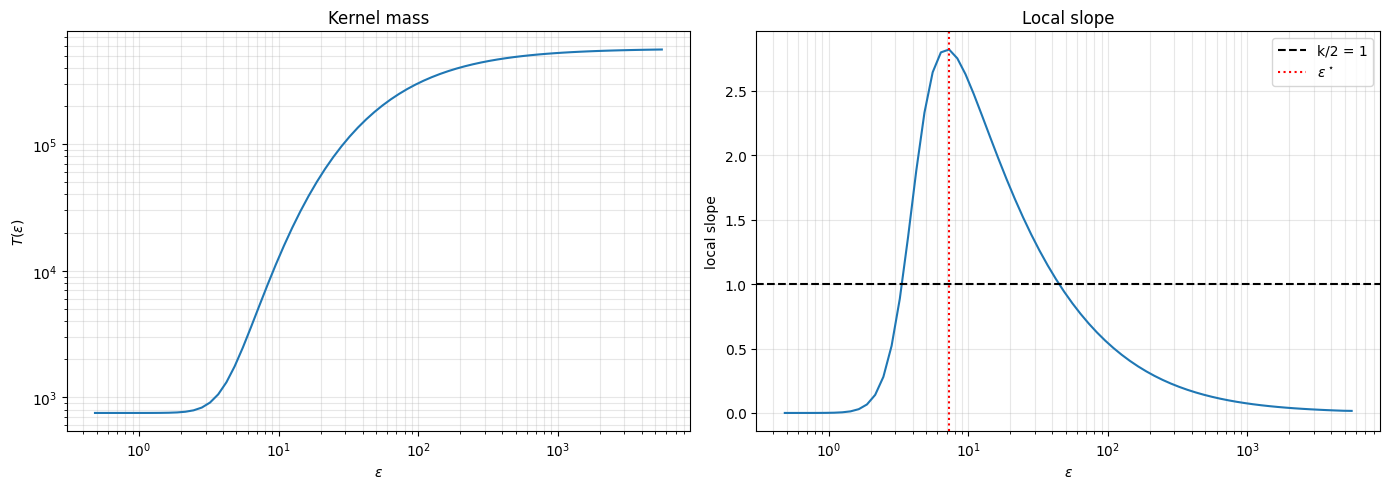

In [18]:
def kernel_mass_slope(data, npts=70, lo=-1.5, hi=2.0):
    Dsq = squareform(pdist(data)**2); n = Dsq.shape[0]
    Dnd = Dsq.copy(); np.fill_diagonal(Dnd, np.inf)
    d_min = np.median(Dnd.min(1)); d_med = np.median(Dsq[np.triu_indices_from(Dsq, 1)])
    grid = np.logspace(np.log10(d_min)+lo, np.log10(d_med)+hi, npts)
    upper = Dsq[np.triu_indices_from(Dsq, 1)]
    T = np.array([2*np.exp(-upper/e).sum() + Dsq.shape[0] for e in grid])
    slope = np.gradient(np.log(T), np.log(grid))
    return grid, T, slope

def select_epsilon(data):
    grid, T, slope = kernel_mass_slope(data)
    i = int(np.argmax(slope))
    lo = max(i-5, 0); hi = min(i+5, len(grid)-1)
    return float(np.sqrt(grid[lo]*grid[hi])), grid, T, slope
Z0 = Z
eps_star, grid, T, slope = select_epsilon(Z0)
print(f"recovered k/2 estimate (max local slope) = {slope.max():.3f}")
print(f"eps_star (D=50, clean)                   = {eps_star:.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.loglog(grid, T); a1.set_xlabel(r"$\varepsilon$"); a1.set_ylabel(r"$T(\varepsilon)$")
a1.set_title("Kernel mass"); a1.grid(which='both', alpha=.3)
a2.semilogx(grid, slope); a2.axhline(1, ls='--', c='k', label="k/2 = 1")
a2.axvline(eps_star, ls=':', c='r', label=r"$\varepsilon^\star$")
a2.set_xlabel(r"$\varepsilon$"); a2.set_ylabel("local slope"); a2.set_title("Local slope")
a2.legend(); a2.grid(which='both', alpha=.3); plt.tight_layout(); plt.show()

Plotting spectrum for different levels of bandwidth

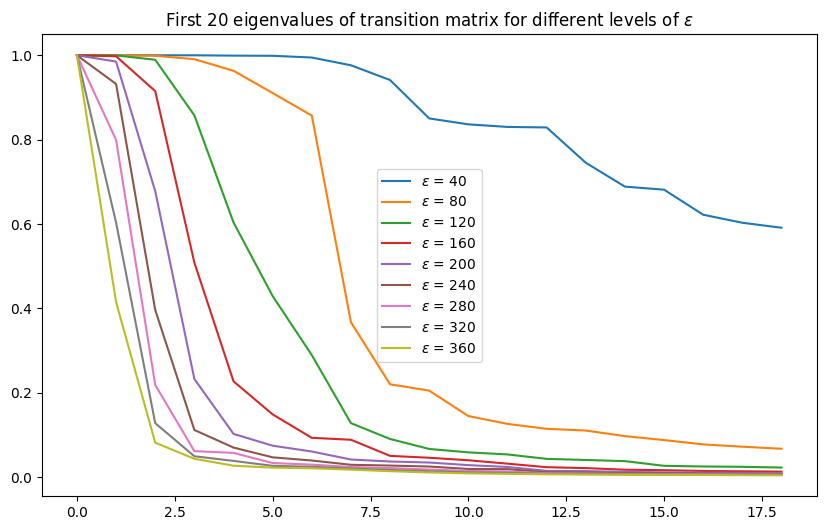

In [19]:
epss = range(40, 385, 40)

trials = len(epss); N = Z.shape[0]; k = 7
Psis = np.zeros((trials, N, k)); evals = []; qs = []

for i, eps in enumerate(epss):
    w, Psi, phi, q = diffusion_map(Z, eps=eps, k=k)

    Psis[i] = Psi
    evals.append(w[1:20])
    qs.append(q)

plt.figure(figsize=(10, 6))
for i, w in enumerate(evals):
    plt.plot(w, label=fr"$\varepsilon$ = {epss[i]}")

plt.title(r"First 20 eigenvalues of transition matrix for different levels of $\varepsilon$")
plt.legend()
plt.show()

In [20]:
rows = []; mins = []

for i, q in enumerate(qs):
    rows.append({"eps": epss[i],"mean": np.mean(q), "Std": np.std(q),"Max": np.max(q), "Min": np.min(q)})
    mins.append(np.argmin(q))

df = pd.DataFrame(rows)
df

,eps,mean,Std,Max,Min
0,40,195.289946,79.399666,339.477645,1.000000
1,80,351.373220,97.033853,484.693730,1.000000
2,120,439.494801,95.466725,553.222003,1.000000
3,160,495.446599,90.416439,593.301960,1.000000
4,200,534.105014,85.080666,619.691766,1.000007
5,240,562.438478,80.176805,638.424246,1.000137
6,280,584.117147,75.824922,652.431891,1.001221
7,320,601.253901,71.991691,663.314610,1.006342
8,360,615.150702,68.610106,672.020722,1.022938


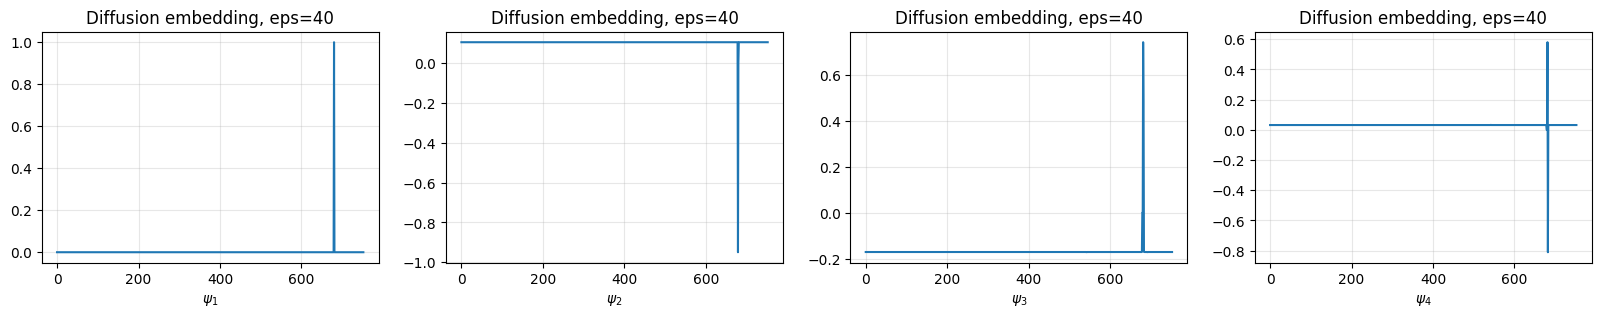

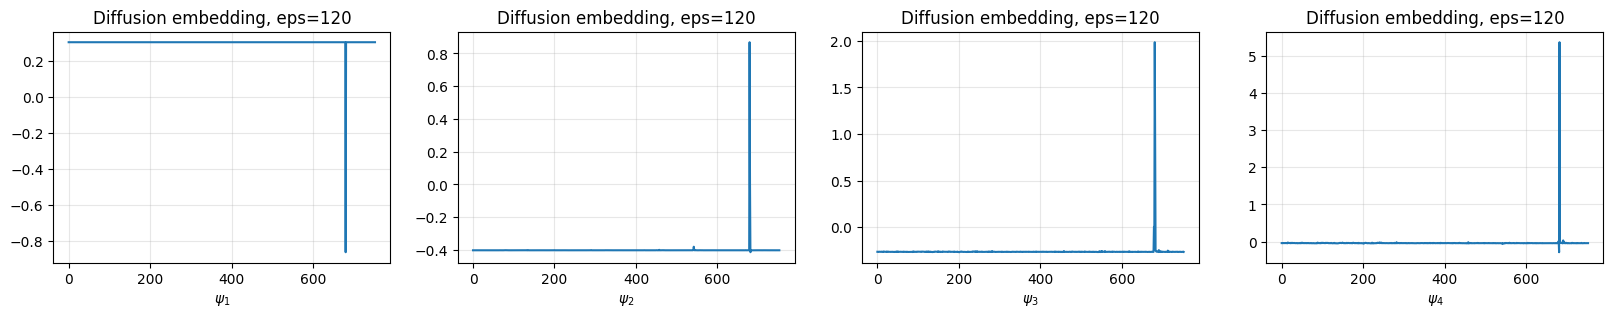

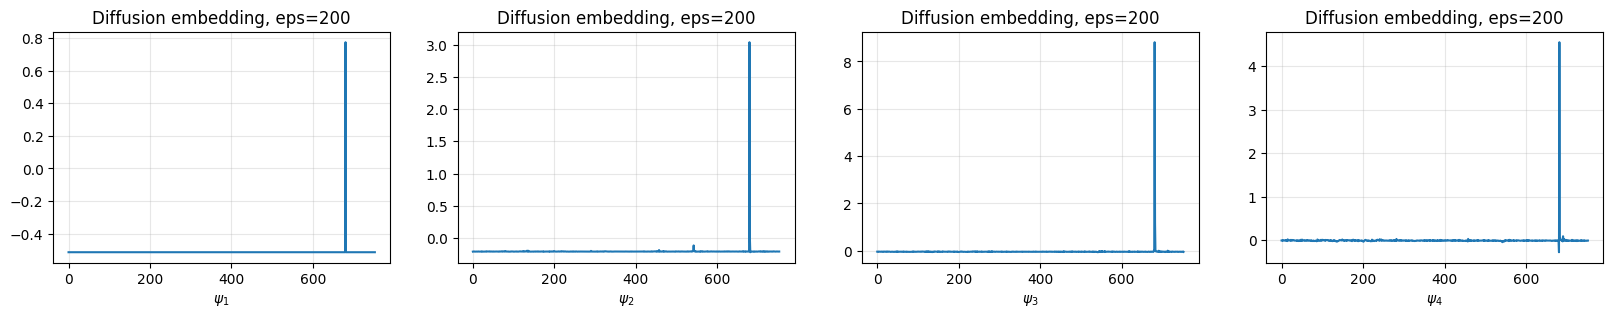

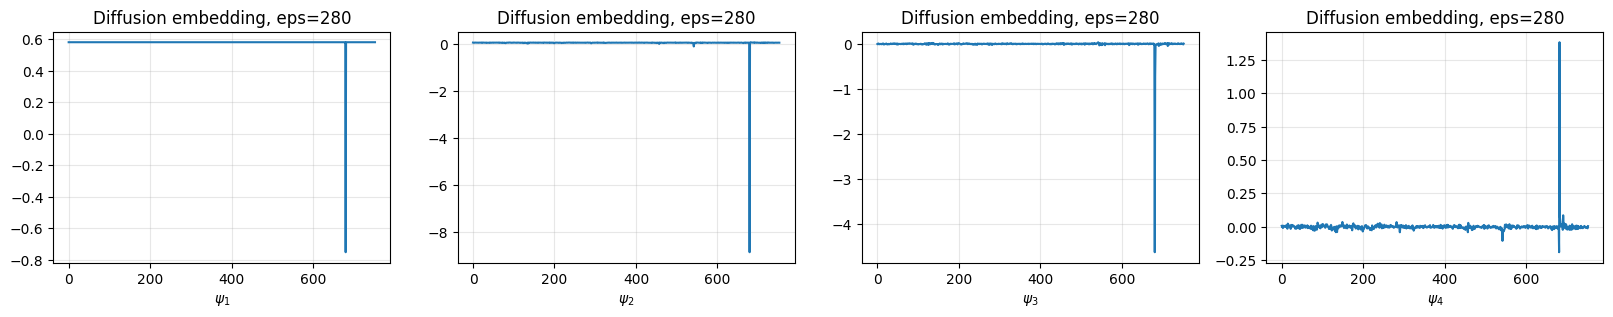

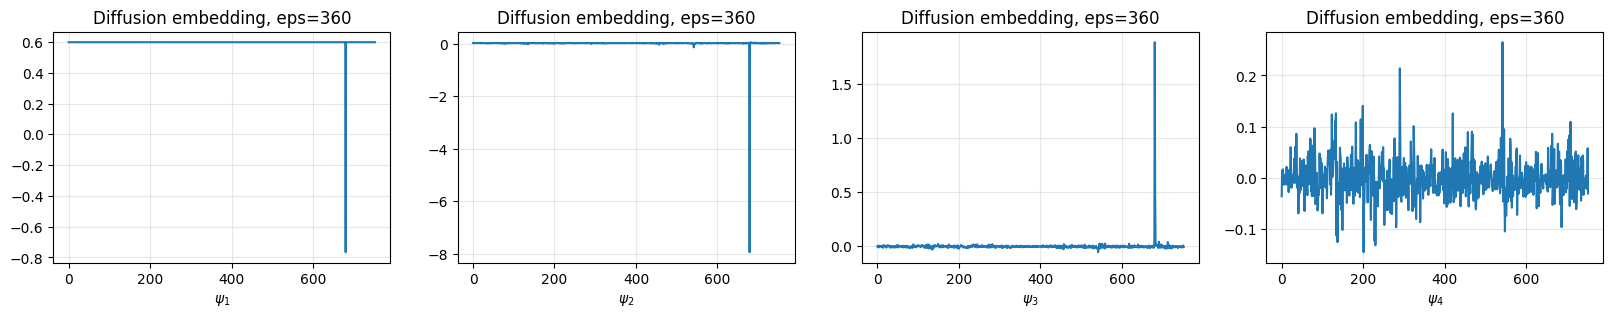

In [21]:
skip = 2
for i, eps in enumerate(epss[::skip]):
    j = i*skip
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)
    fig.set_figwidth(20); fig.set_figheight(3)
    ax1.plot(Psis[j,:,0]); ax1.set_title(f"Diffusion embedding, eps={eps}")
    ax1.set_xlabel(r"$\psi_1$"); ax1.grid(alpha=0.3)

    ax2.plot(Psis[j,:,1]); ax2.set_title(f"Diffusion embedding, eps={eps}")
    ax2.set_xlabel(r"$\psi_2$"); ax2.grid(alpha=0.3)
    ax3.plot(Psis[j,:,2]); ax3.set_title(f"Diffusion embedding, eps={eps}")
    ax3.set_xlabel(r"$\psi_3$"); ax3.grid(alpha=0.3)
    ax4.plot(Psis[j,:,3]); ax4.set_title(f"Diffusion embedding, eps={eps}")
    ax4.set_xlabel(r"$\psi_4$"); ax4.grid(alpha=0.3)
    plt.show()

The first three coordinates always only pick up the COVID spike. Only after $\varepsilon = 280$ do we start to see diffusion coordinates with lots of information, but I think for an epsilon this large, we can't be learning much about the manifold.

### Removing a few months around covid

In [24]:
Z = np.load("./datasets/Z.npy")
df = pd.read_parquet("./datasets/observation_df.parquet")

covid = [678, 679, 680, 681, 682]
Z = np.delete(Z, (covid), axis=0)
df.drop(df.index[covid], axis=0, inplace=True)

dates = df.index; variables = df.columns
Z.shape

(748, 45)

Degree vector statistics for different bandwidths
           mean        Std         Max         Min
eps                                               
40   196.233297  78.292600  339.234609    1.022411
80   352.926396  93.794770  484.199940    3.628967
120  441.354840  90.158005  552.588086   16.557507
160  497.459500  83.246334  592.563839   40.303209
200  536.173349  76.296635  618.858057   70.400087
240  564.497214  70.022462  637.495691  102.933484
280  586.122867  64.519986  651.407984  135.507042
320  603.178122  59.725350  662.195569  166.852301
360  616.975309  55.541167  670.807839  196.378297


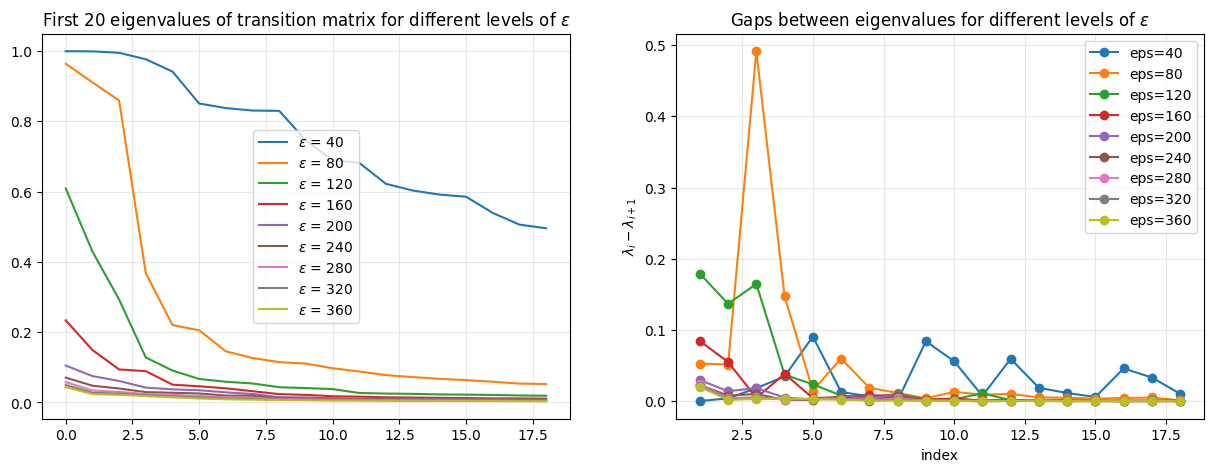

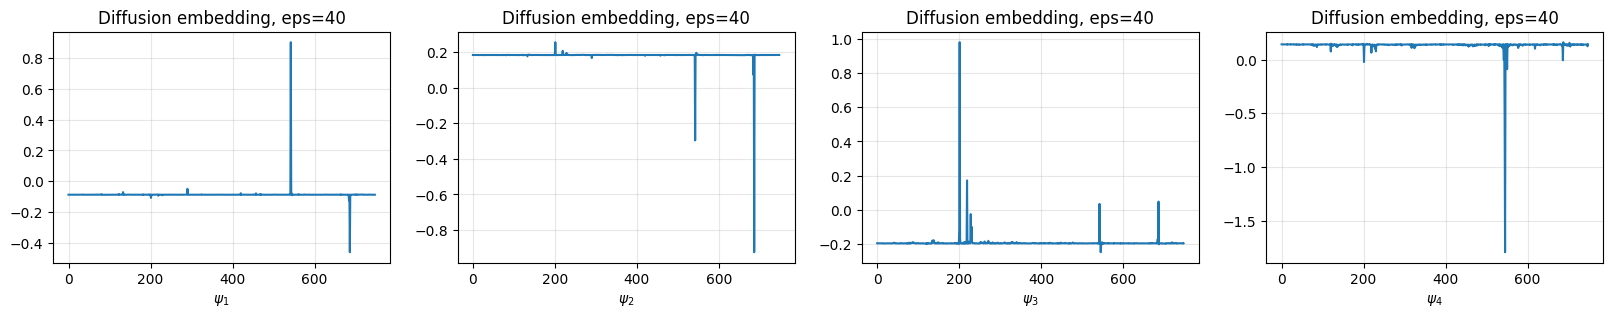

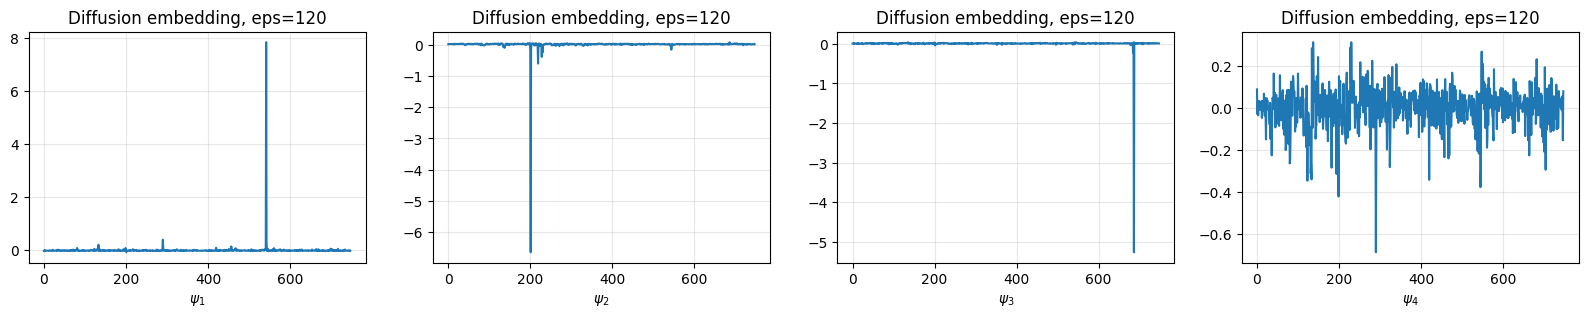

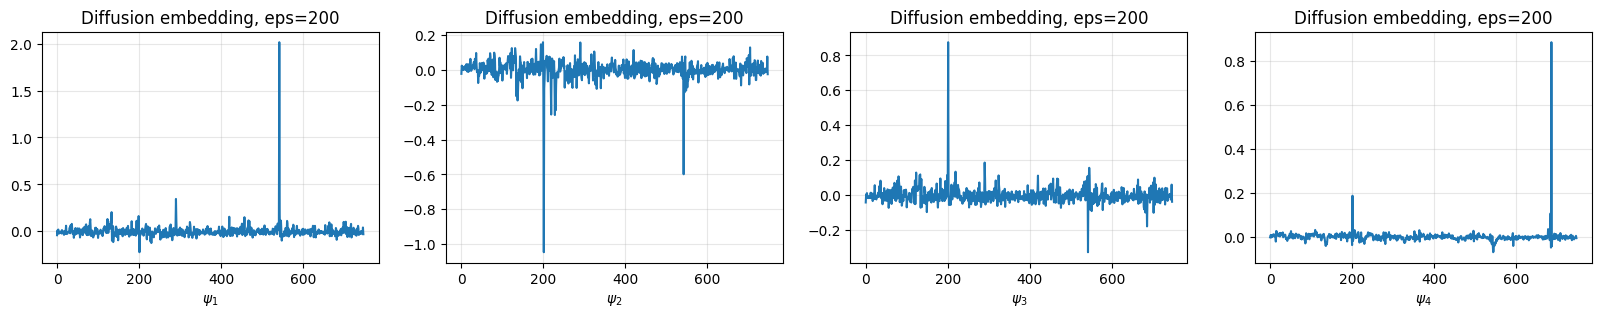

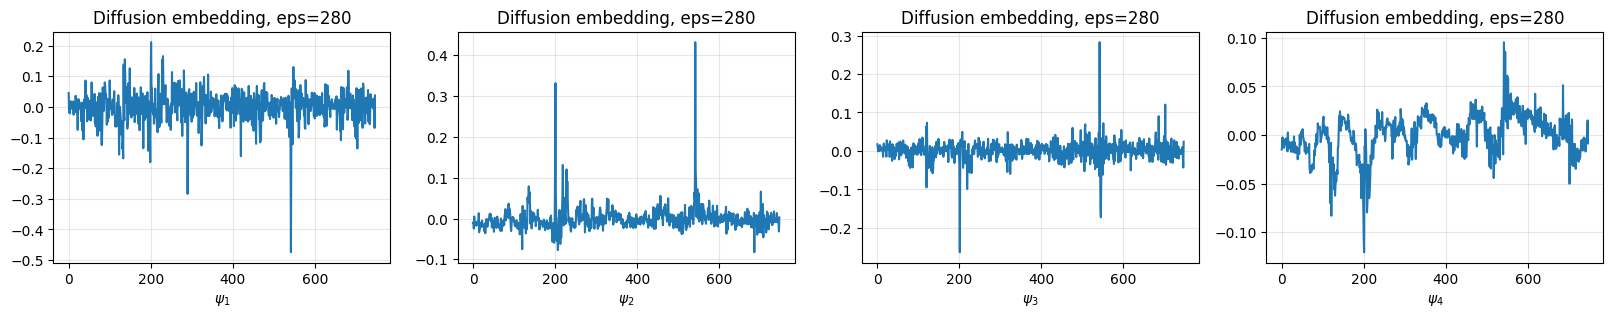

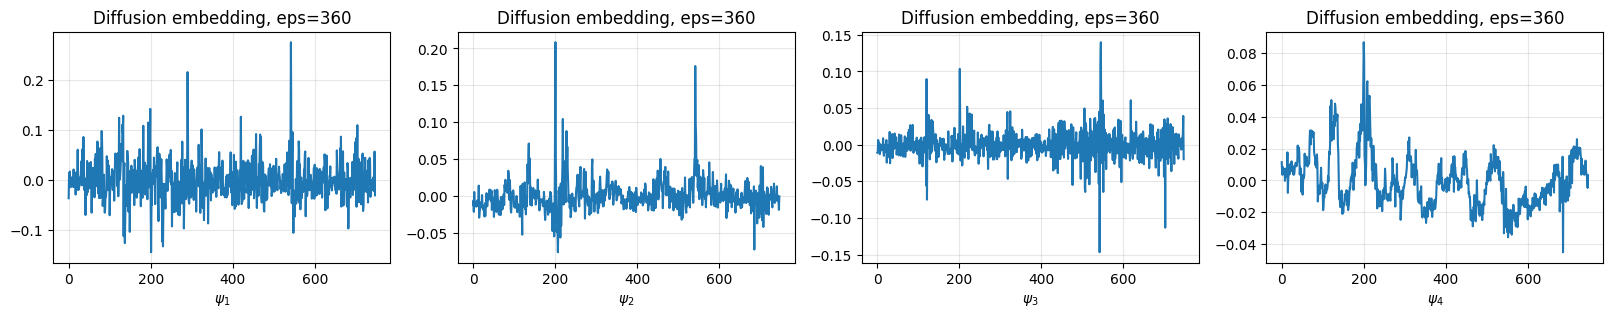

In [26]:
epss = range(40, 385, 40)

trials = len(epss); N = Z.shape[0]; k = 7
Psis = np.zeros((trials, N, k)); evals = []; qs = []

for i, eps in enumerate(epss):
    w, Psi, phi, q = diffusion_map(Z, eps=eps, k=k)

    Psis[i] = Psi
    evals.append(w[1:20])
    qs.append(q)


### Degree dataframe
rows = []; mins = []
for i, q in enumerate(qs):
    rows.append({"eps": epss[i],"mean": np.mean(q), "Std": np.std(q),"Max": np.max(q), "Min": np.min(q)})
    mins.append(np.argmin(q))

df = pd.DataFrame(rows)
df.set_index("eps", inplace=True)
print("Degree vector statistics for different bandwidths")
print(df)


### Eigenvalue plots
fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(5); fig.set_figwidth(15)
for i, w in enumerate(evals):
    ax1.plot(w, label=fr"$\varepsilon$ = {epss[i]}")
ax1.set_title(r"First 20 eigenvalues of transition matrix for different levels of $\varepsilon$")
ax1.grid(alpha=0.3)
ax1.legend()

gaps = [e[:-1] - e[1:] for e in evals]
for eps, gap in zip(epss, gaps):
    ax2.plot(np.arange(1, len(gap)+1), gap, marker="o", label=f"eps={eps}")

ax2.set_title(r"Gaps between eigenvalues for different levels of $\varepsilon$")
ax2.set_xlabel("index")
ax2.set_ylabel(r"$\lambda_i-\lambda_{i+1}$")
ax2.grid(alpha=0.3)
ax2.legend()
plt.show()


skip = 2
for i, eps in enumerate(epss[::skip]):
    j = i*skip
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)
    fig.set_figwidth(20); fig.set_figheight(3)
    ax1.plot(Psis[j,:,0]); ax1.set_title(f"Diffusion embedding, eps={eps}")
    ax1.set_xlabel(r"$\psi_1$"); ax1.grid(alpha=0.3)

    ax2.plot(Psis[j,:,1]); ax2.set_title(f"Diffusion embedding, eps={eps}")
    ax2.set_xlabel(r"$\psi_2$"); ax2.grid(alpha=0.3)
    ax3.plot(Psis[j,:,2]); ax3.set_title(f"Diffusion embedding, eps={eps}")
    ax3.set_xlabel(r"$\psi_3$"); ax3.grid(alpha=0.3)
    ax4.plot(Psis[j,:,3]); ax4.set_title(f"Diffusion embedding, eps={eps}")
    ax4.set_xlabel(r"$\psi_4$"); ax4.grid(alpha=0.3)
    plt.show()

For $\varepsilon = 120$ the first 3 diffusion coordinates seem to be picking up on something different which is good, but they still has only have big spikes, instead of looking like they have lots of information. The eigenvalue plot doesn't look like what I would have hoped for.

### Clipping the $\tilde Z$ values

In [10]:
Z = np.load("./datasets/Z.npy")
df = pd.read_parquet("./datasets/observation_df.parquet")

Z = np.clip(Z, a_min=-4, a_max=4)

dates = df.index; variables = df.columns
Z.shape

(753, 45)

Degree vector statistics for different bandwidths
           mean        Std         Max         Min
eps                                               
40   196.233297  78.292600  339.234609    1.022411
80   352.926396  93.794770  484.199940    3.628967
120  441.354840  90.158005  552.588086   16.557507
160  497.459500  83.246334  592.563839   40.303209
200  536.173349  76.296635  618.858057   70.400087
240  564.497214  70.022462  637.495691  102.933484
280  586.122867  64.519986  651.407984  135.507042
320  603.178122  59.725350  662.195569  166.852301
360  616.975309  55.541167  670.807839  196.378297


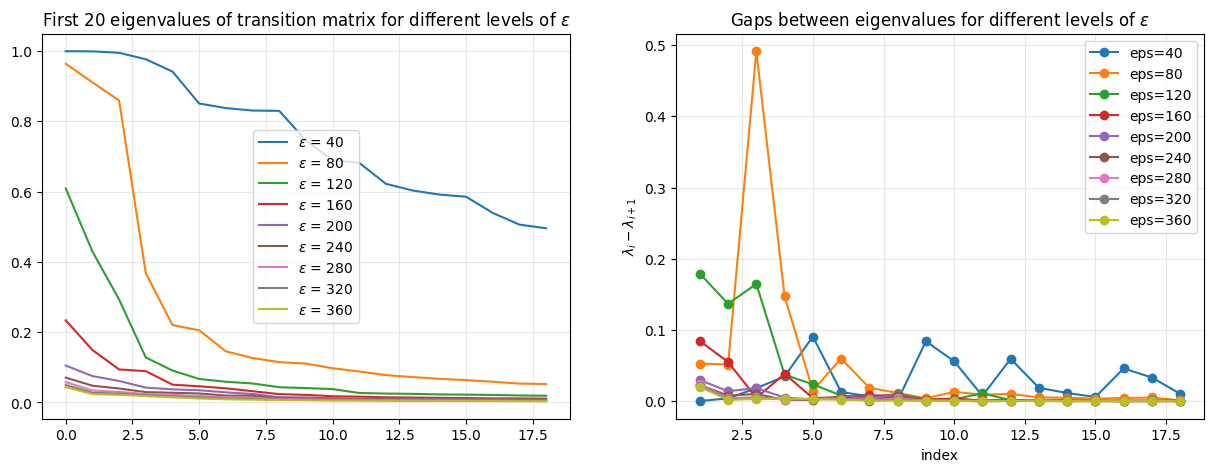

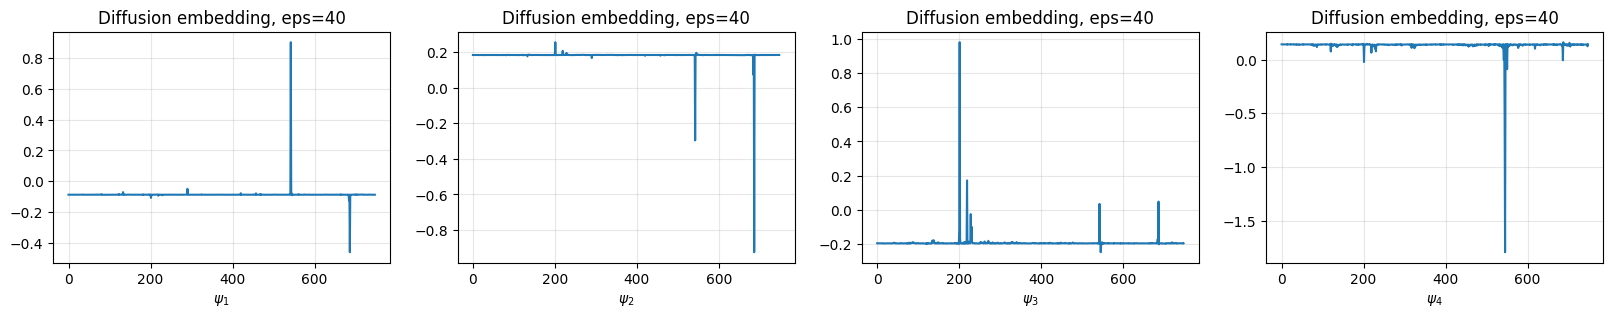

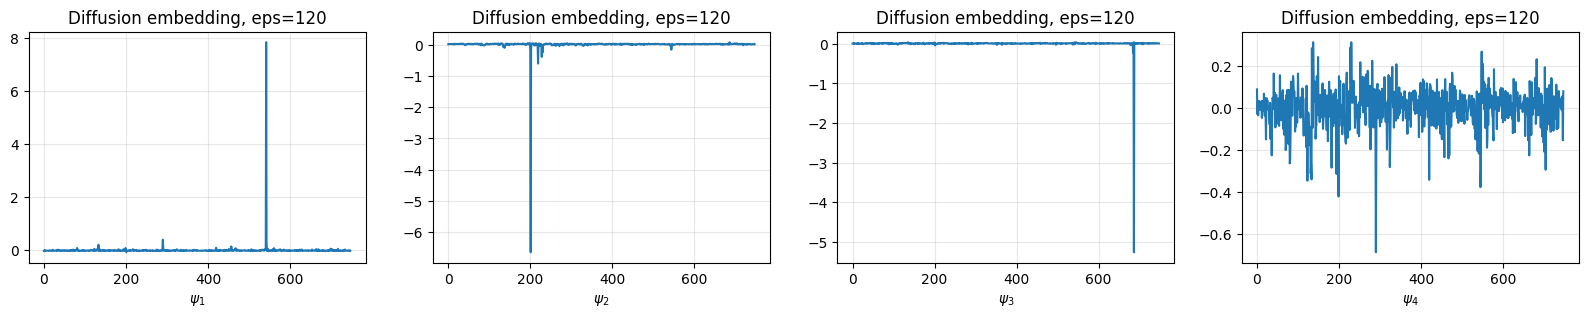

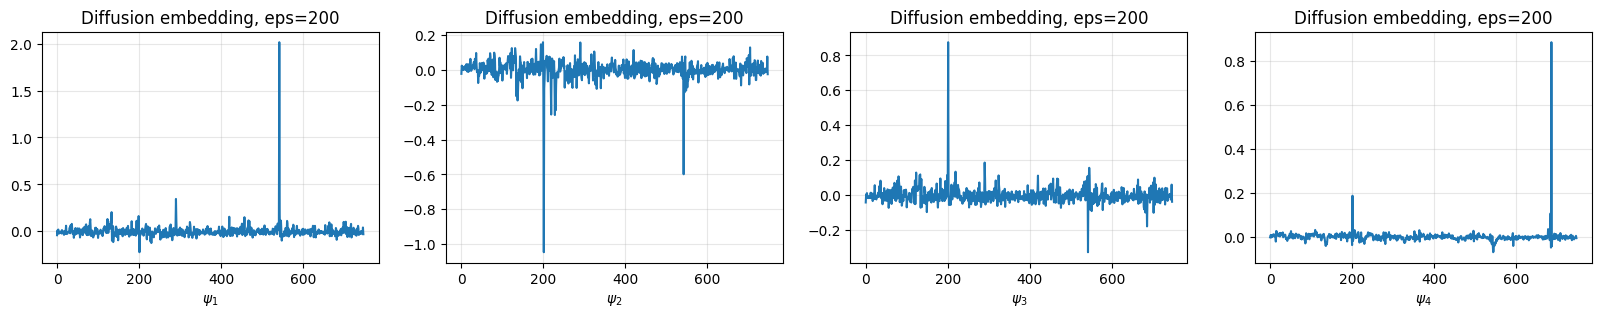

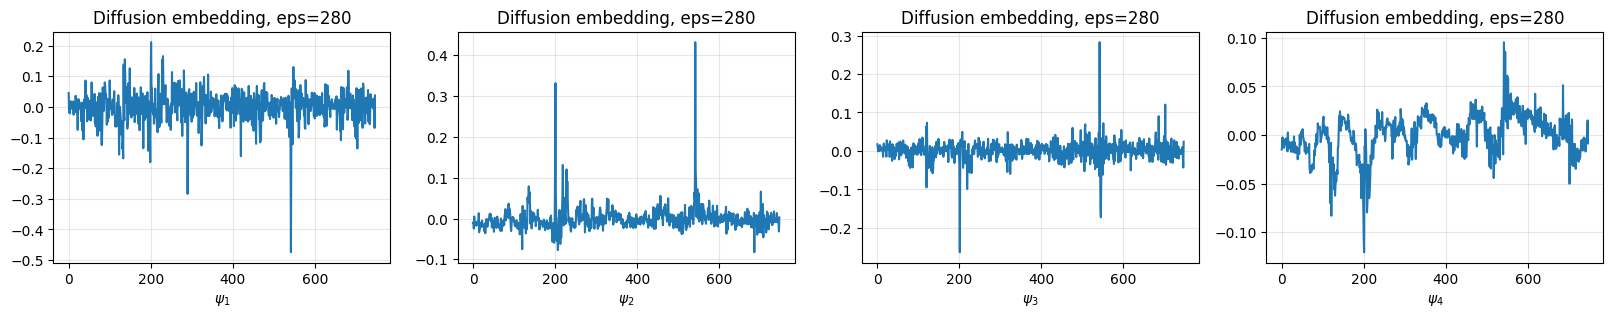

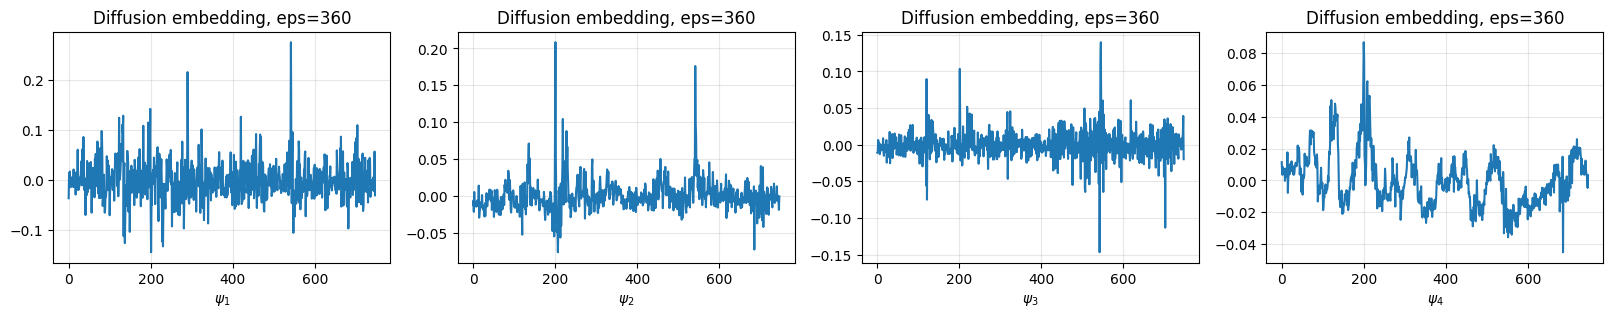

In [27]:
epss = range(40, 385, 40)

trials = len(epss); N = Z.shape[0]; k = 7
Psis = np.zeros((trials, N, k)); evals = []; qs = []

for i, eps in enumerate(epss):
    w, Psi, phi, q = diffusion_map(Z, eps=eps, k=k)

    Psis[i] = Psi
    evals.append(w[1:20])
    qs.append(q)


### Degree dataframe
rows = []; mins = []
for i, q in enumerate(qs):
    rows.append({"eps": epss[i],"mean": np.mean(q), "Std": np.std(q),"Max": np.max(q), "Min": np.min(q)})
    mins.append(np.argmin(q))

df = pd.DataFrame(rows)
df.set_index("eps", inplace=True)
print("Degree vector statistics for different bandwidths")
print(df)


### Eigenvalue plots
fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(5); fig.set_figwidth(15)
for i, w in enumerate(evals):
    ax1.plot(w, label=fr"$\varepsilon$ = {epss[i]}")
ax1.set_title(r"First 20 eigenvalues of transition matrix for different levels of $\varepsilon$")
ax1.grid(alpha=0.3)
ax1.legend()

gaps = [e[:-1] - e[1:] for e in evals]
for eps, gap in zip(epss, gaps):
    ax2.plot(np.arange(1, len(gap)+1), gap, marker="o", label=f"eps={eps}")

ax2.set_title(r"Gaps between eigenvalues for different levels of $\varepsilon$")
ax2.set_xlabel("index")
ax2.set_ylabel(r"$\lambda_i-\lambda_{i+1}$")
ax2.grid(alpha=0.3)
ax2.legend()
plt.show()


skip = 2
for i, eps in enumerate(epss[::skip]):
    j = i*skip
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)
    fig.set_figwidth(20); fig.set_figheight(3)
    ax1.plot(Psis[j,:,0]); ax1.set_title(f"Diffusion embedding, eps={eps}")
    ax1.set_xlabel(r"$\psi_1$"); ax1.grid(alpha=0.3)

    ax2.plot(Psis[j,:,1]); ax2.set_title(f"Diffusion embedding, eps={eps}")
    ax2.set_xlabel(r"$\psi_2$"); ax2.grid(alpha=0.3)
    ax3.plot(Psis[j,:,2]); ax3.set_title(f"Diffusion embedding, eps={eps}")
    ax3.set_xlabel(r"$\psi_3$"); ax3.grid(alpha=0.3)
    ax4.plot(Psis[j,:,3]); ax4.set_title(f"Diffusion embedding, eps={eps}")
    ax4.set_xlabel(r"$\psi_4$"); ax4.grid(alpha=0.3)
    plt.show()

These coordinate plots look a litte better, but I am changing the raw data...

### Rough plots, on coordinates that I don't understand yet

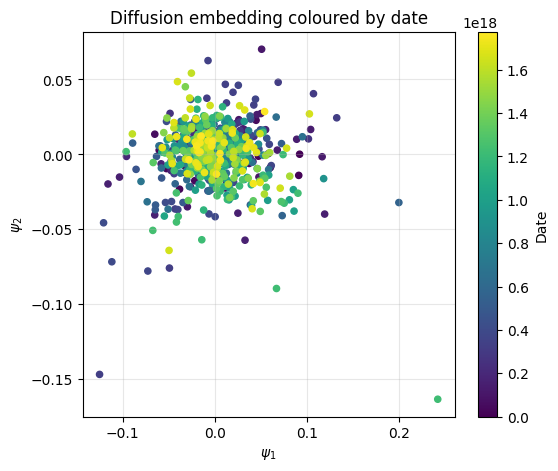

In [134]:
plt.figure(figsize=(6, 5))


sc = plt.scatter(
    Psi[:, 0],
    Psi[:, 1],
    c=dates,
    s=20,
    cmap="viridis"
)

plt.xlabel(r"$\psi_1$")
plt.ylabel(r"$\psi_2$")
plt.title(r"Diffusion embedding coloured by date")
plt.colorbar(sc, label="Date")
plt.grid(alpha=0.3)
plt.show()

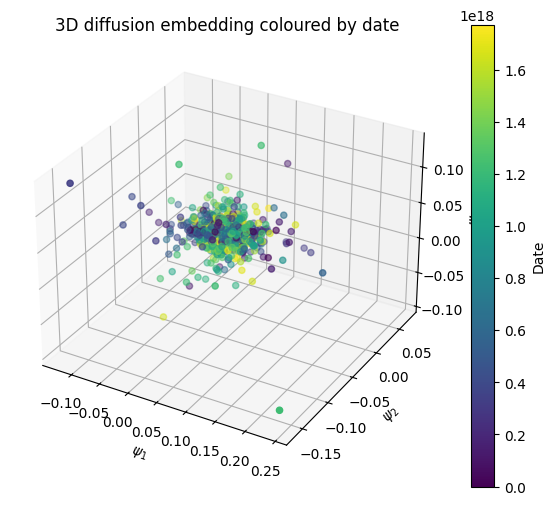

In [132]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    Psi[:, 0],
    Psi[:, 1],
    Psi[:, 2],
    c=dates,
    s=20,
    cmap="viridis"
)

ax.set_xlabel(r"$\psi_1$")
ax.set_ylabel(r"$\psi_2$")
ax.set_zlabel(r"$\psi_3$")
ax.set_title(r"3D diffusion embedding coloured by date")

fig.colorbar(sc, ax=ax, label="Date")
plt.show()